# Competition Data Analysis & Insights
Exploratory analysis for the Hedge Fund Time Series Forecasting competition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, adfuller, pacf
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load data
train = pd.read_parquet('/kaggle/input/ts-forecasting/train.parquet')
test = pd.read_parquet('/kaggle/input/ts-forecasting/test.parquet')

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'\nTrain columns: {len(train.columns)}')
print(f'Test columns: {len(test.columns)}')

Train shape: (5337414, 94)
Test shape: (1447107, 92)

Train columns: 94
Test columns: 92


## 1. Basic Statistics

In [3]:
print('=== CATEGORICAL VARIABLES ===')
print(f"Unique codes: {train['code'].nunique()}")
print(f"Unique sub_codes: {train['sub_code'].nunique()}")
print(f"Unique sub_categories: {train['sub_category'].nunique()}")
print(f"\nHorizon values: {sorted(train['horizon'].unique())}")
print(f"\nHorizon distribution:")
print(train['horizon'].value_counts().sort_index())

=== CATEGORICAL VARIABLES ===
Unique codes: 23
Unique sub_codes: 180
Unique sub_categories: 5

Horizon values: [np.int32(1), np.int32(3), np.int32(10), np.int32(25)]

Horizon distribution:
horizon
1     1394653
3     1385816
10    1337236
25    1219709
Name: count, dtype: int64


In [4]:
print('=== TEMPORAL STRUCTURE ===')
print(f"Train ts_index range: {train['ts_index'].min()} to {train['ts_index'].max()}")
print(f"Test ts_index range: {test['ts_index'].min()} to {test['ts_index'].max()}")
print(f"\nTemporal gap (test comes after train): {test['ts_index'].min() > train['ts_index'].max()}")
print(f"\nUnique ts_index in train: {train['ts_index'].nunique()}")
print(f"Unique ts_index in test: {test['ts_index'].nunique()}")

=== TEMPORAL STRUCTURE ===
Train ts_index range: 1 to 3601
Test ts_index range: 3602 to 4376

Temporal gap (test comes after train): True

Unique ts_index in train: 3601
Unique ts_index in test: 775


In [5]:
print('=== TARGET VARIABLE ===')
print(train['y_target'].describe())
print(f"\nTarget mean: {train['y_target'].mean():.6f}")
print(f"Target std: {train['y_target'].std():.6f}")
print(f"Target median: {train['y_target'].median():.6f}")
print(f"\nZeros in target: {(train['y_target'] == 0).sum()} ({(train['y_target'] == 0).mean()*100:.2f}%)")

=== TARGET VARIABLE ===
count    5.337414e+06
mean    -6.659048e-01
std      3.252764e+01
min     -2.201882e+03
25%     -1.290776e-01
50%     -5.774818e-04
75%      5.106807e-02
max      2.314411e+03
Name: y_target, dtype: float64

Target mean: -0.665905
Target std: 32.527642
Target median: -0.000577

Zeros in target: 1628 (0.03%)


In [6]:
print('=== WEIGHTS ===')
print(train['weight'].describe())
print(f"\nWeight distribution by horizon:")
print(train.groupby('horizon')['weight'].describe())

=== WEIGHTS ===
count    5.337414e+06
mean     1.642788e+07
std      6.027074e+09
min      0.000000e+00
25%      1.553378e+01
50%      1.699384e+03
75%      1.641908e+05
max      1.391222e+13
Name: weight, dtype: float64

Weight distribution by horizon:
             count          mean           std  min        25%          50%  \
horizon                                                                       
1        1394653.0  1.668640e+07  4.269101e+08  0.0  20.624701  2301.884698   
3        1385816.0  2.366432e+07  1.181908e+10  0.0  16.172558  1804.246490   
10       1337236.0  1.175030e+07  1.244036e+08  0.0  13.560641  1517.371631   
25       1219709.0  1.303864e+07  1.417457e+08  0.0  12.336823  1318.564934   

                   75%           max  
horizon                               
1        218474.813566  4.787166e+11  
3        172003.016362  1.391222e+13  
10       143786.855978  6.144323e+10  
25       131901.550485  2.219142e+10  


### Weight Distribution and Statsmodels Structure

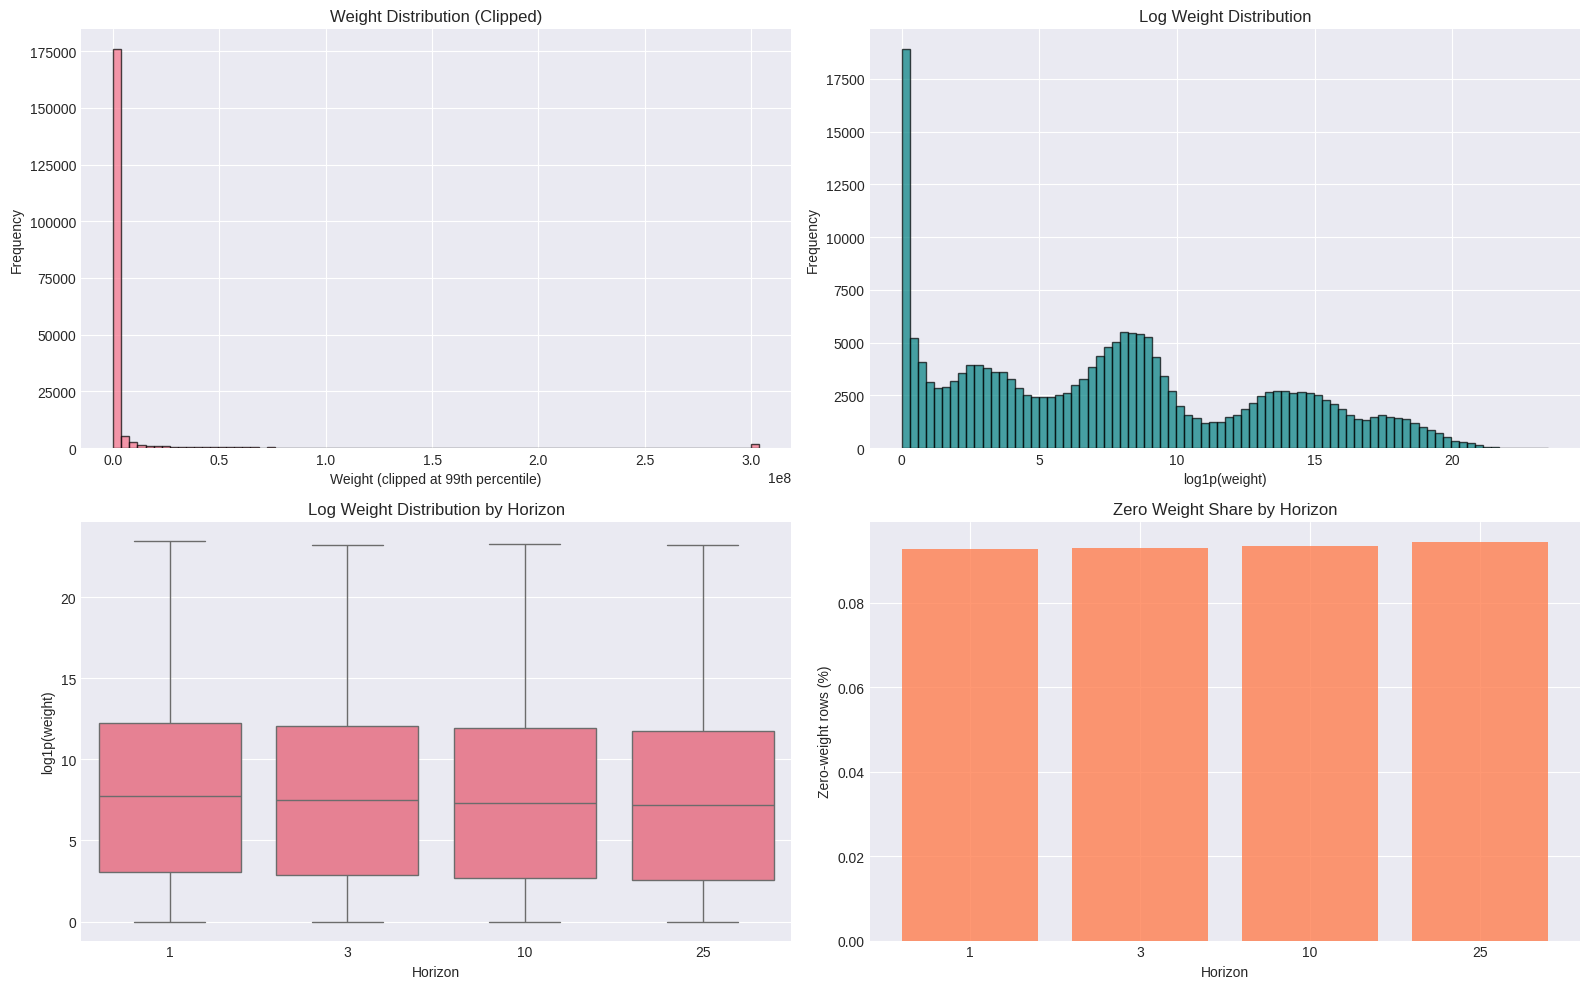

Weight quantiles:
0.00    0.000000e+00
0.01    3.162972e-03
0.05    1.655505e-02
0.25    1.553378e+01
0.50    1.699384e+03
0.75    1.641908e+05
0.95    4.317066e+07
0.99    3.038408e+08
1.00    1.391222e+13
Name: weight, dtype: float64


In [7]:
# Weight distribution graph
weight_plot = train[['weight', 'horizon']].dropna().copy()
weight_plot['log_weight'] = np.log1p(weight_plot['weight'])
weight_sample = weight_plot.sample(
    n=min(200_000, len(weight_plot)),
    random_state=42
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

p99_weight = train['weight'].quantile(0.99)
axes[0].hist(
    weight_sample['weight'].clip(upper=p99_weight),
    bins=80,
    edgecolor='black',
    alpha=0.7
)
axes[0].set_xlabel('Weight (clipped at 99th percentile)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Weight Distribution (Clipped)')

axes[1].hist(
    weight_sample['log_weight'],
    bins=80,
    edgecolor='black',
    alpha=0.7,
    color='teal'
)
axes[1].set_xlabel('log1p(weight)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log Weight Distribution')

sns.boxplot(data=weight_sample, x='horizon', y='log_weight', ax=axes[2])
axes[2].set_xlabel('Horizon')
axes[2].set_ylabel('log1p(weight)')
axes[2].set_title('Log Weight Distribution by Horizon')

zero_weight_share = (
    train.groupby('horizon')['weight']
    .apply(lambda s: (s == 0).mean() * 100)
    .sort_index()
)
axes[3].bar(
    zero_weight_share.index.astype(str),
    zero_weight_share.values,
    color='coral',
    alpha=0.8
)
axes[3].set_xlabel('Horizon')
axes[3].set_ylabel('Zero-weight rows (%)')
axes[3].set_title('Zero Weight Share by Horizon')

plt.tight_layout()
plt.show()

print('Weight quantiles:')
print(train['weight'].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

Weight time series used for statsmodels: mean log1p(weight) by ts_index
count    3601.000000
mean        7.578041
std         1.208863
min         0.045220
25%         7.330441
50%         7.796372
75%         8.199597
max         9.953092
Name: mean_log1p_weight, dtype: float64
Missing ts_index values filled before diagnostics: 0

Seasonality strength by candidate period:
   period  seasonal_strength
0      50           0.227779
1      25           0.159629
2      20           0.113001
3     100           0.092651
4       5           0.007165
5       7           0.006324
6      10           0.005338
7       3           0.002298

Using period=50 for STL decomposition.


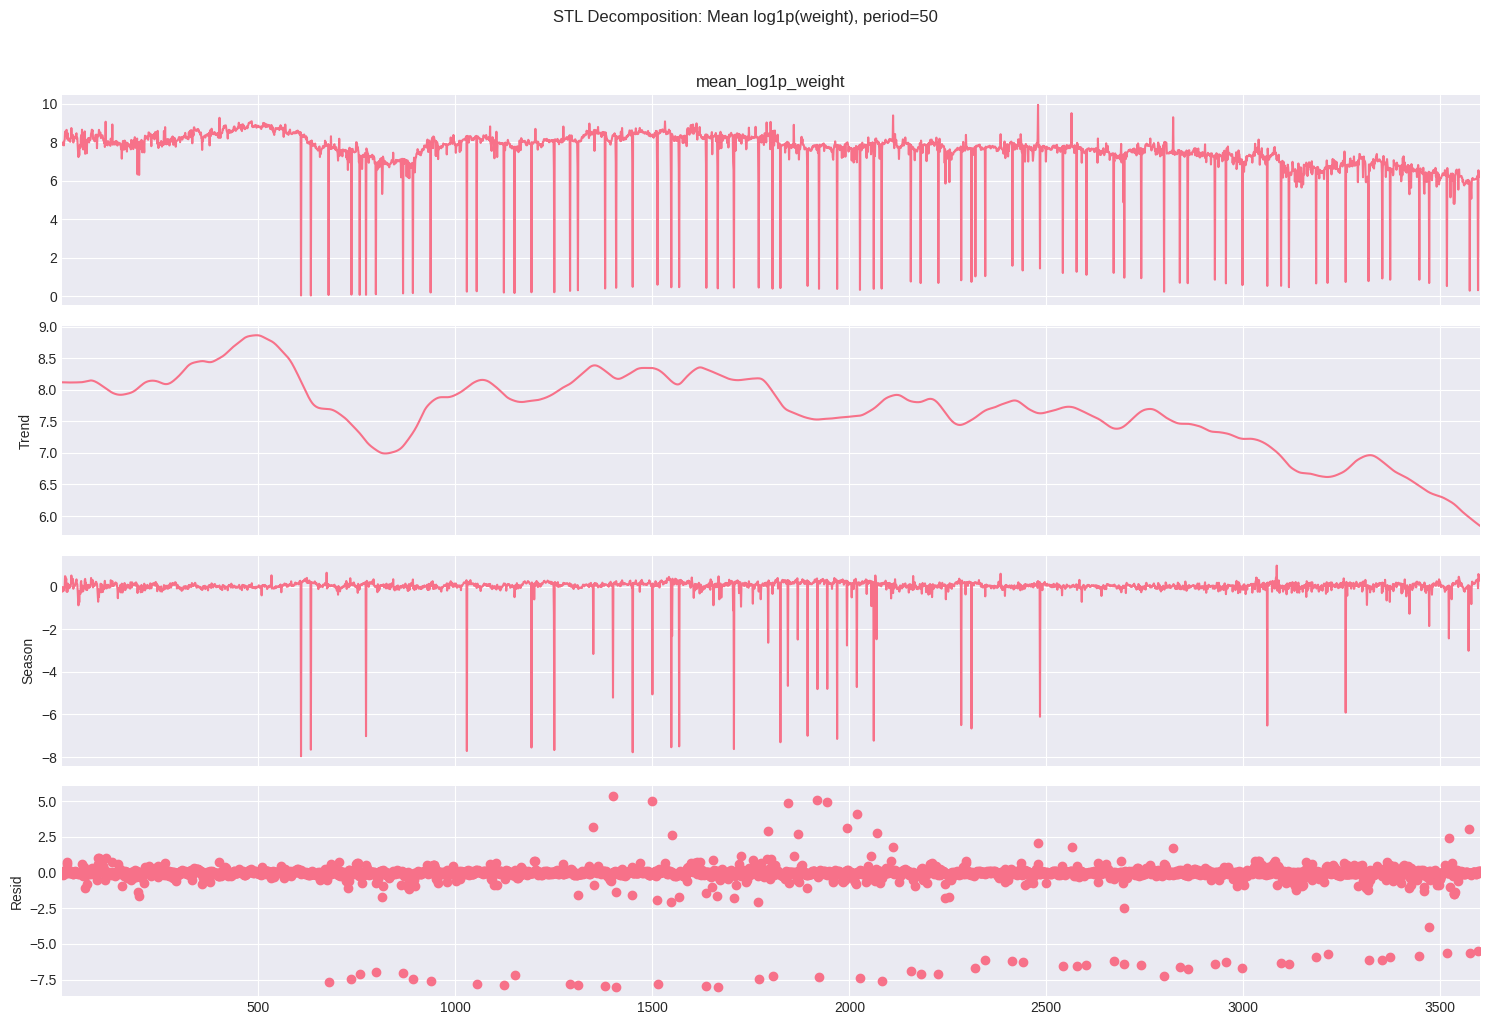

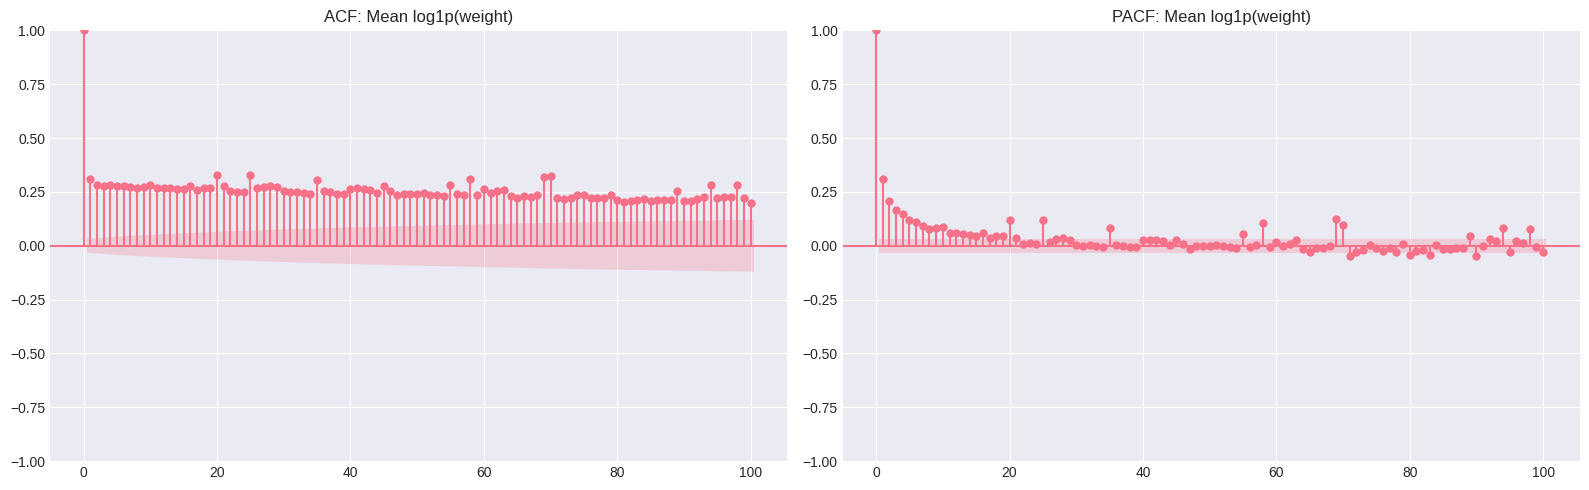


Top serial lags by absolute ACF:
    lag       acf      pacf
24   25  0.329910  0.119198
19   20  0.328227  0.120143
69   70  0.324452  0.097679
68   69  0.320776  0.126207
0     1  0.311794  0.311794
57   58  0.307761  0.106612
34   35  0.304235  0.082211
97   98  0.283541  0.079038
1     2  0.283380  0.206211
54   55  0.282860  0.053555
3     4  0.282528  0.148969
9    10  0.281026  0.085063
93   94  0.280355  0.081513
5     6  0.278150  0.111675
20   21  0.277618  0.037775

Candidate seasonal lags in the serial structure:
    lag       acf      pacf
2     3  0.276557  0.164422
4     5  0.275200  0.120134
6     7  0.272118  0.092697
9    10  0.281026  0.085063
19   20  0.328227  0.120143
24   25  0.329910  0.119198
49   50  0.241745 -0.003196
99  100  0.198080 -0.028693

ADF stationarity test for mean log1p(weight):
ADF statistic: -2.6142
p-value: 0.0901
used lag: 28, observations: 3572
critical values: {'1%': np.float64(-3.4321820284304763), '5%': np.float64(-2.862349487253214), '1

In [8]:
# Statsmodels seasonal and serial structure for weights
weight_ts = (
    train[['ts_index', 'weight']]
    .assign(log_weight=lambda df: np.log1p(df['weight']))
    .groupby('ts_index')['log_weight']
    .mean()
    .sort_index()
)

full_ts_index = np.arange(weight_ts.index.min(), weight_ts.index.max() + 1)
missing_ts_count = int(weight_ts.reindex(full_ts_index).isna().sum())
weight_ts = (
    weight_ts.reindex(full_ts_index)
    .interpolate(method='linear')
    .ffill()
    .bfill()
)
weight_ts.name = 'mean_log1p_weight'

print('Weight time series used for statsmodels: mean log1p(weight) by ts_index')
print(weight_ts.describe())
print(f'Missing ts_index values filled before diagnostics: {missing_ts_count}')

candidate_periods = [3, 5, 7, 10, 20, 25, 50, 100]
candidate_periods = [period for period in candidate_periods if len(weight_ts) >= (2 * period + 1)]
seasonality_rows = []

for period in candidate_periods:
    stl_fit = STL(weight_ts, period=period, robust=True).fit()
    denom = np.nanvar(stl_fit.resid + stl_fit.seasonal)
    strength = max(0, 1 - np.nanvar(stl_fit.resid) / (denom + 1e-12))
    seasonality_rows.append({
        'period': period,
        'seasonal_strength': strength
    })

seasonality_strength = (
    pd.DataFrame(seasonality_rows)
    .sort_values('seasonal_strength', ascending=False)
    .reset_index(drop=True)
)

print('\nSeasonality strength by candidate period:')
print(seasonality_strength)

seasonal_period = int(seasonality_strength.loc[0, 'period']) if len(seasonality_strength) else 25
print(f'\nUsing period={seasonal_period} for STL decomposition.')

stl_result = STL(weight_ts, period=seasonal_period, robust=True).fit()
fig = stl_result.plot()
fig.set_size_inches(15, 10)
fig.suptitle(f'STL Decomposition: Mean log1p(weight), period={seasonal_period}', y=1.02)
plt.tight_layout()
plt.show()

max_lag = min(100, len(weight_ts) // 4)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(weight_ts, lags=max_lag, ax=axes[0], alpha=0.05, fft=True)
axes[0].set_title('ACF: Mean log1p(weight)')
plot_pacf(weight_ts, lags=max_lag, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF: Mean log1p(weight)')
plt.tight_layout()
plt.show()

acf_values = acf(weight_ts, nlags=max_lag, fft=True)
pacf_values = pacf(weight_ts, nlags=max_lag, method='ywm')
serial_structure = (
    pd.DataFrame({
        'lag': np.arange(1, max_lag + 1),
        'acf': acf_values[1:],
        'pacf': pacf_values[1:]
    })
    .assign(
        abs_acf=lambda df: df['acf'].abs(),
        abs_pacf=lambda df: df['pacf'].abs()
    )
)

print('\nTop serial lags by absolute ACF:')
print(serial_structure.sort_values('abs_acf', ascending=False).head(15)[['lag', 'acf', 'pacf']])

print('\nCandidate seasonal lags in the serial structure:')
print(serial_structure[serial_structure['lag'].isin(candidate_periods)][['lag', 'acf', 'pacf']])

adf_stat, adf_pvalue, used_lag, nobs, critical_values, icbest = adfuller(weight_ts, autolag='AIC')
print('\nADF stationarity test for mean log1p(weight):')
print(f'ADF statistic: {adf_stat:.4f}')
print(f'p-value: {adf_pvalue:.4g}')
print(f'used lag: {used_lag}, observations: {nobs}')
print('critical values:', critical_values)

## 2. Missing Values Analysis

In [9]:
# Missing values in train
missing_train = train.isnull().sum()
missing_train_pct = (missing_train / len(train)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_train[missing_train > 0],
    'Missing_Percent': missing_train_pct[missing_train > 0]
}).sort_values('Missing_Percent', ascending=False)

print('=== MISSING VALUES IN TRAIN ===')
print(f"Columns with missing values: {len(missing_df)}")
print(f"\nTop 10 columns with most missing values:")
print(missing_df.head(10))

=== MISSING VALUES IN TRAIN ===
Columns with missing values: 48

Top 10 columns with most missing values:
            Missing_Count  Missing_Percent
feature_at         665676        12.471882
feature_by         588140        11.019194
feature_ay         455920         8.541964
feature_cd         400114         7.496402
feature_ce         275829         5.167840
feature_cf         236389         4.428905
feature_al         225416         4.223319
feature_aw         205194         3.844446
feature_bz         151722         2.842613
feature_bi         147432         2.762237


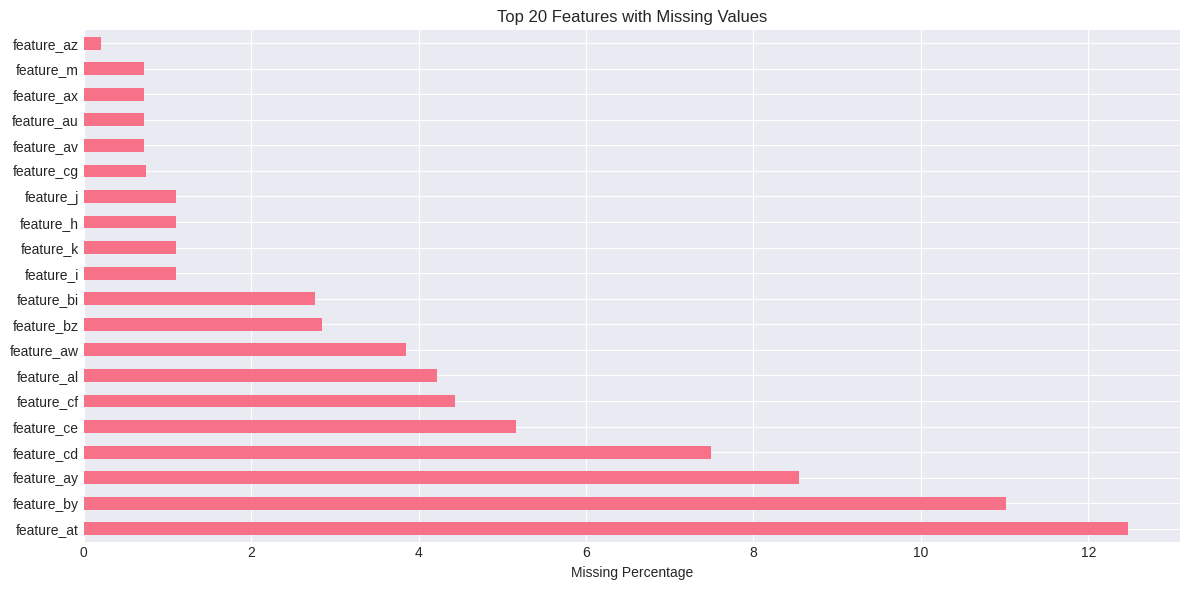

In [10]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df.head(20)['Missing_Percent'].plot(kind='barh', ax=ax)
    ax.set_xlabel('Missing Percentage')
    ax.set_title('Top 20 Features with Missing Values')
    plt.tight_layout()
    plt.show()

## 3. Target Distribution Analysis

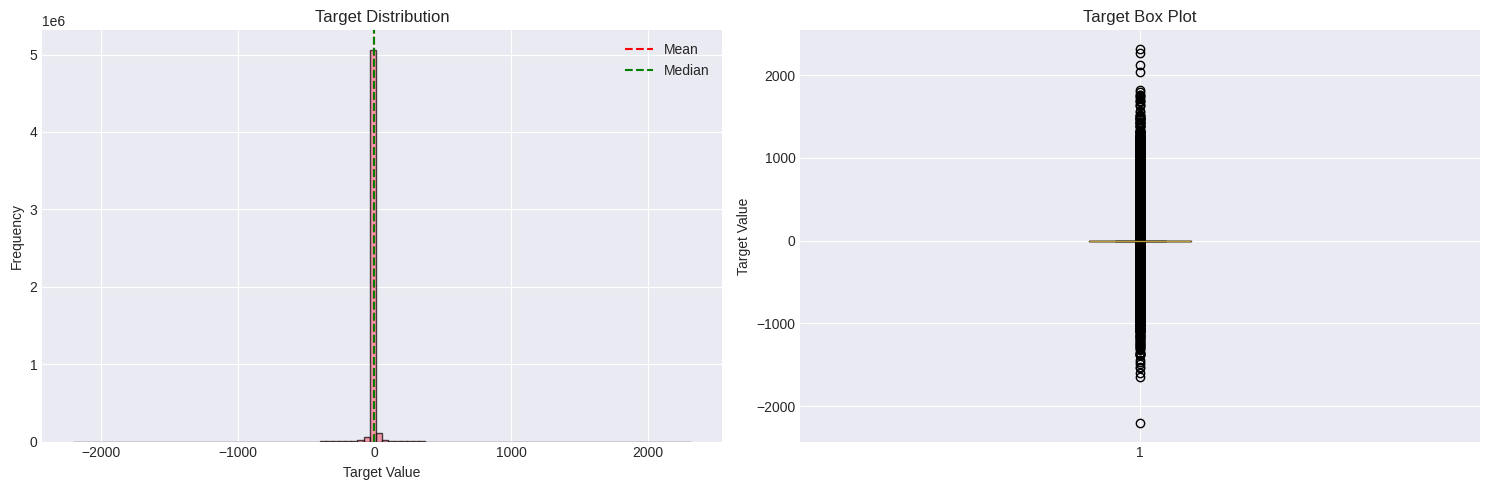

In [11]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(train['y_target'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Target Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution')
axes[0].axvline(train['y_target'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(train['y_target'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Box plot
axes[1].boxplot(train['y_target'], vert=True)
axes[1].set_ylabel('Target Value')
axes[1].set_title('Target Box Plot')

plt.tight_layout()
plt.show()

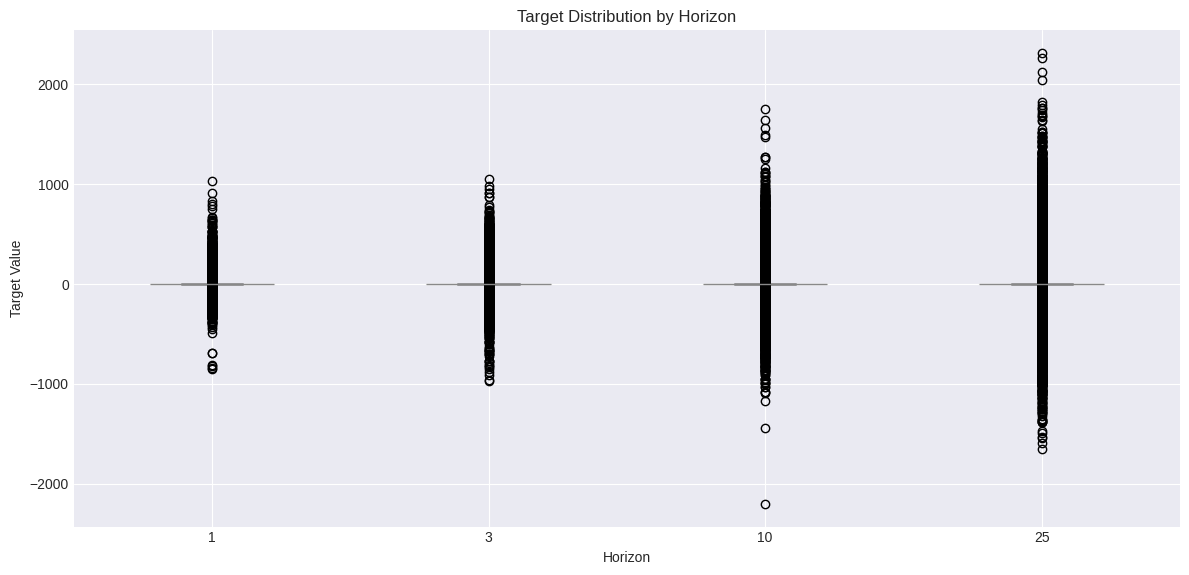


Target statistics by horizon:
             count      mean        std          min       25%       50%  \
horizon                                                                    
1        1394653.0 -0.082721  11.699685  -855.023057 -0.050663 -0.000243   
3        1385816.0 -0.252409  19.361190  -974.575239 -0.091504 -0.000400   
10       1337236.0 -0.775965  33.842065 -2201.881578 -0.184004 -0.000917   
25       1219709.0 -1.681878  52.823280 -1646.887504 -0.318943 -0.001865   

              75%          max  
horizon                         
1        0.023475  1033.607926  
3        0.044363  1049.831766  
10       0.075232  1751.756630  
25       0.114019  2314.411152  


In [12]:
# Target by horizon
fig, ax = plt.subplots(figsize=(12, 6))

train.boxplot(column='y_target', by='horizon', ax=ax)
ax.set_xlabel('Horizon')
ax.set_ylabel('Target Value')
ax.set_title('Target Distribution by Horizon')
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

print('\nTarget statistics by horizon:')
print(train.groupby('horizon')['y_target'].describe())

## 4. Temporal Patterns

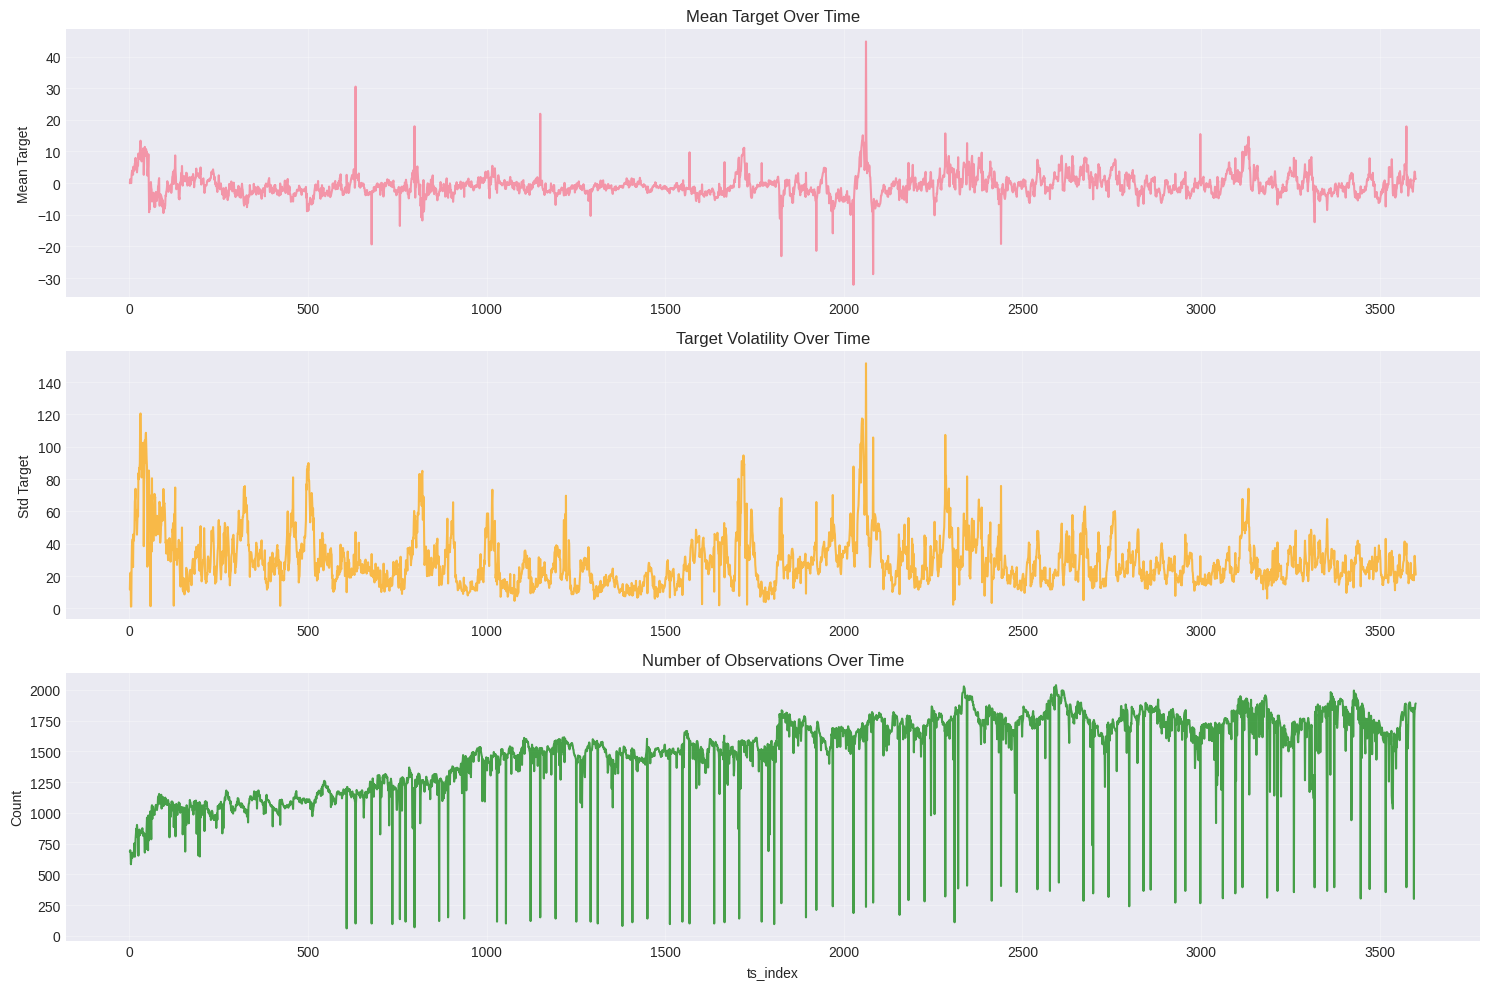

In [13]:
# Target over time
temporal_stats = train.groupby('ts_index')['y_target'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Mean over time
axes[0].plot(temporal_stats.index, temporal_stats['mean'], alpha=0.7)
axes[0].set_ylabel('Mean Target')
axes[0].set_title('Mean Target Over Time')
axes[0].grid(True, alpha=0.3)

# Std over time
axes[1].plot(temporal_stats.index, temporal_stats['std'], alpha=0.7, color='orange')
axes[1].set_ylabel('Std Target')
axes[1].set_title('Target Volatility Over Time')
axes[1].grid(True, alpha=0.3)

# Count over time
axes[2].plot(temporal_stats.index, temporal_stats['count'], alpha=0.7, color='green')
axes[2].set_xlabel('ts_index')
axes[2].set_ylabel('Count')
axes[2].set_title('Number of Observations Over Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

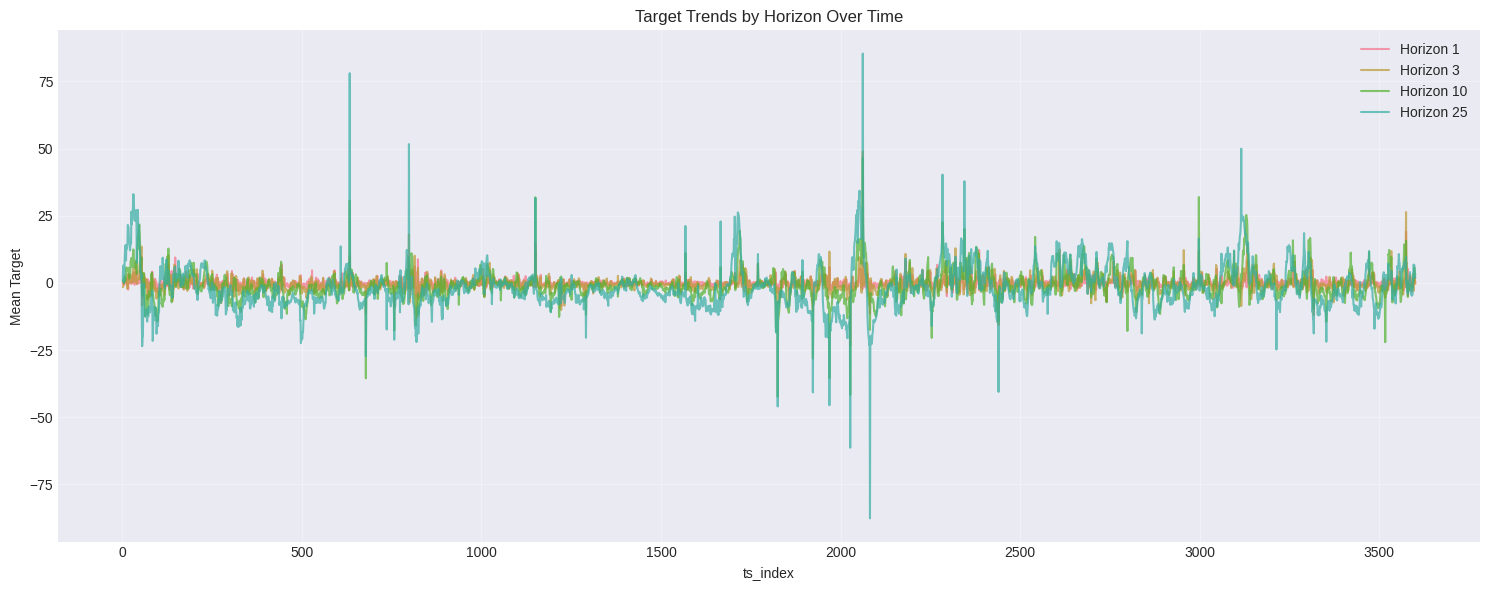

In [14]:
# Target by horizon over time
fig, ax = plt.subplots(figsize=(15, 6))

for horizon in sorted(train['horizon'].unique()):
    horizon_data = train[train['horizon'] == horizon].groupby('ts_index')['y_target'].mean()
    ax.plot(horizon_data.index, horizon_data.values, label=f'Horizon {horizon}', alpha=0.7)

ax.set_xlabel('ts_index')
ax.set_ylabel('Mean Target')
ax.set_title('Target Trends by Horizon Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feature Analysis

In [15]:
# Correlation with target
feature_cols = [col for col in train.columns if col.startswith('feature_')]

correlations = train[feature_cols + ['y_target']].corr()['y_target'].drop('y_target').sort_values(ascending=False)

print('=== TOP 20 FEATURES BY CORRELATION WITH TARGET ===')
print(correlations.head(20))

print('\n=== BOTTOM 20 FEATURES BY CORRELATION WITH TARGET ===')
print(correlations.tail(20))

=== TOP 20 FEATURES BY CORRELATION WITH TARGET ===
feature_bz    0.090461
feature_cd    0.085975
feature_by    0.025680
feature_bg    0.021508
feature_cc    0.017016
feature_cf    0.016188
feature_m     0.014570
feature_bv    0.013384
feature_a     0.012855
feature_ch    0.012707
feature_cb    0.011295
feature_ai    0.011182
feature_bp    0.010611
feature_ar    0.009567
feature_ad    0.008947
feature_aj    0.008381
feature_j     0.008325
feature_at    0.007998
feature_ab    0.007171
feature_ac    0.007013
Name: y_target, dtype: float64

=== BOTTOM 20 FEATURES BY CORRELATION WITH TARGET ===
feature_ah   -0.014461
feature_n    -0.016073
feature_bn   -0.016427
feature_ae   -0.016557
feature_aq   -0.017065
feature_p    -0.017898
feature_bw   -0.019895
feature_h    -0.025394
feature_l    -0.027329
feature_v    -0.029046
feature_k    -0.029943
feature_t    -0.032575
feature_am   -0.034625
feature_o    -0.036360
feature_ag   -0.044977
feature_s    -0.046017
feature_bm   -0.054569
feature_bo  

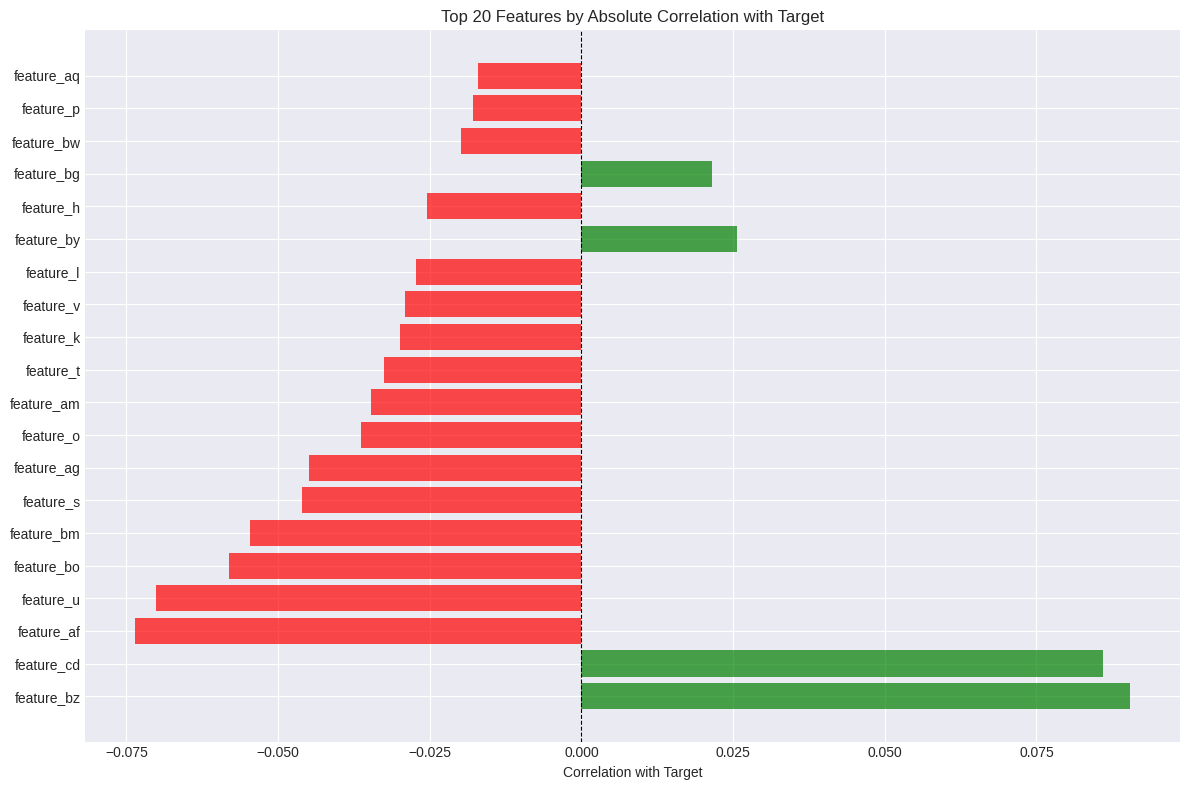

In [16]:
# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))

top_20 = correlations.abs().sort_values(ascending=False).head(20)
colors = ['green' if correlations[feat] > 0 else 'red' for feat in top_20.index]

ax.barh(range(len(top_20)), correlations[top_20.index], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.set_xlabel('Correlation with Target')
ax.set_title('Top 20 Features by Absolute Correlation with Target')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

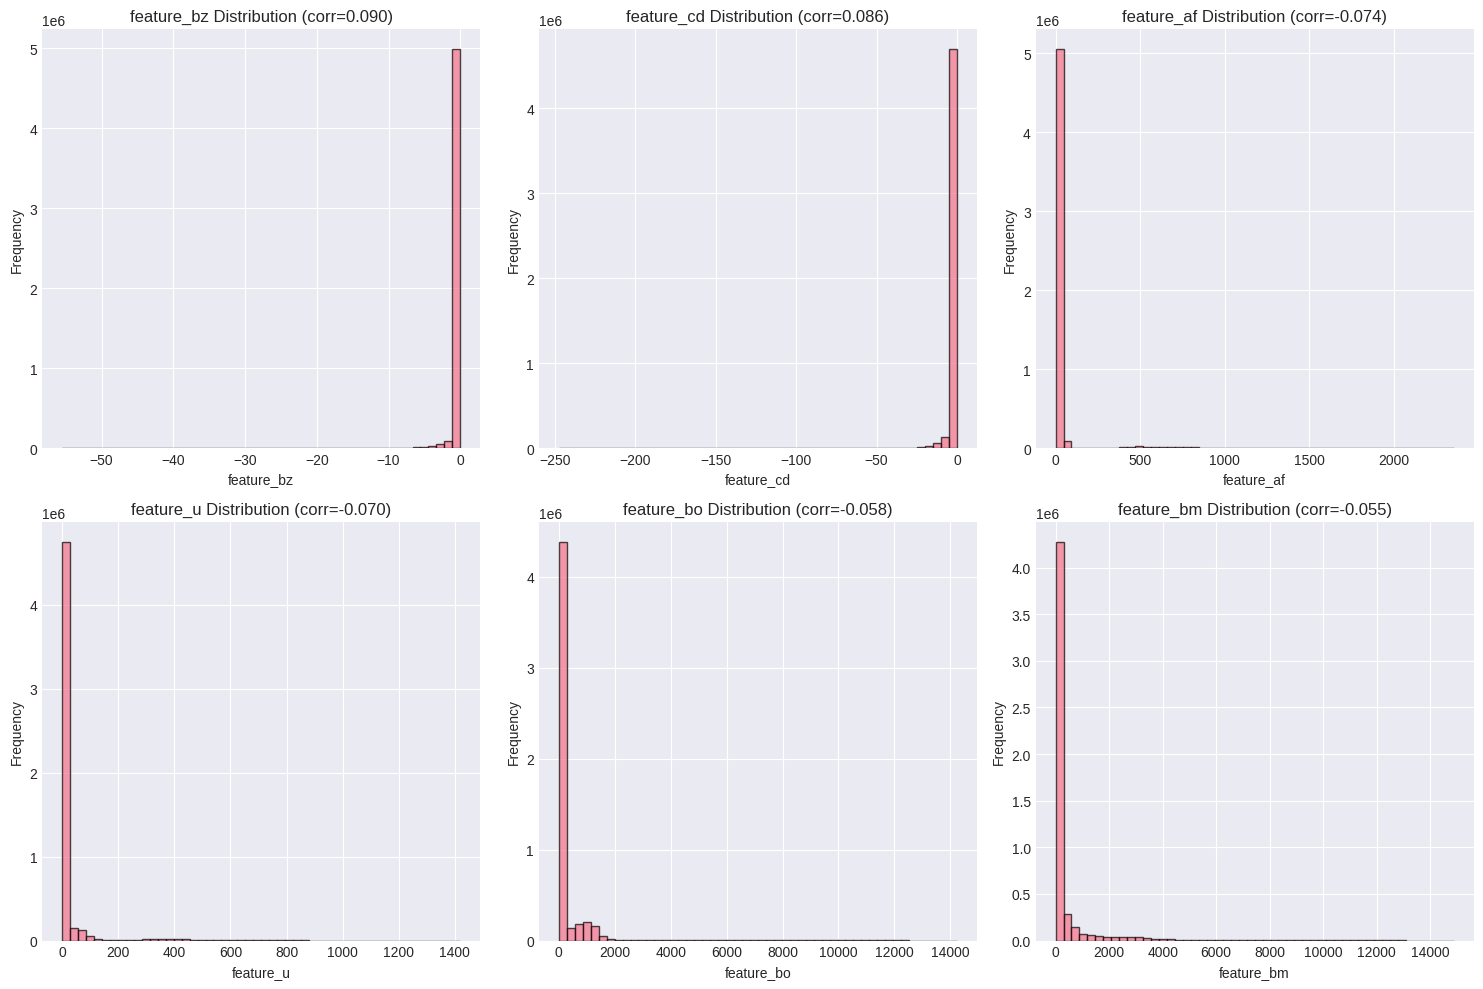

In [17]:
# Feature distributions for top features
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    axes[idx].hist(train[feat].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{feat} Distribution (corr={correlations[feat]:.3f})')

plt.tight_layout()
plt.show()

## 6. Category Analysis

In [18]:
# Target statistics by code
code_stats = train.groupby('code')['y_target'].agg(['count', 'mean', 'std'])
code_stats = code_stats.sort_values('count', ascending=False).head(20)

print('=== TOP 20 CODES BY FREQUENCY ===')
print(code_stats)

=== TOP 20 CODES BY FREQUENCY ===
           count       mean         std
code                                   
OSJL3A7Y  564790  -0.041594    1.879662
6LB028J8  484082   0.003549    0.221563
K7Y1TTAH  324479  -0.595550    6.807219
VFWIFJPS  318517   0.000410    0.013920
W2MW3G2L  305116  -0.022722    0.374298
1HEMHZK2  293024   0.000137    0.007241
660DZME0  264071   0.008396    2.005410
4KUR2ZOZ  263685  -0.008763    0.346717
SJZP0OVU  237283  -0.000056    0.002014
84J8BJFZ  234375   0.007242    0.403669
MRV5UON2  223256  -0.009117    0.154076
K8I5QG74  222146  -0.003182    0.109787
EP12UF2K  213164  -0.000280    0.009603
X9BZ68VQ  209261  -0.166515    7.676776
W4S29LF4  193977 -10.952807  142.610537
MLAAMU3K  184735  -0.000136    0.004476
2RBMUWP1  176409  -0.941983   15.612861
10BAVIDU  134886  -0.977455   14.637540
QAQDDTPJ  130876  -6.299555  109.241238
83EG83KQ  118694   0.000018    0.000919


=== SUB_CATEGORY STATISTICS ===
                count      mean        std
sub_category                              
PZ9S1Z4V      1074239 -1.217609  28.187398
DPPUO5X2      1072705 -0.180652  29.266238
NQ58FVQM      1067164 -0.997217  19.832982
PHHHVYZI      1067164 -1.446897  53.455295
V8BKY1IV      1056142  0.526302  19.532539


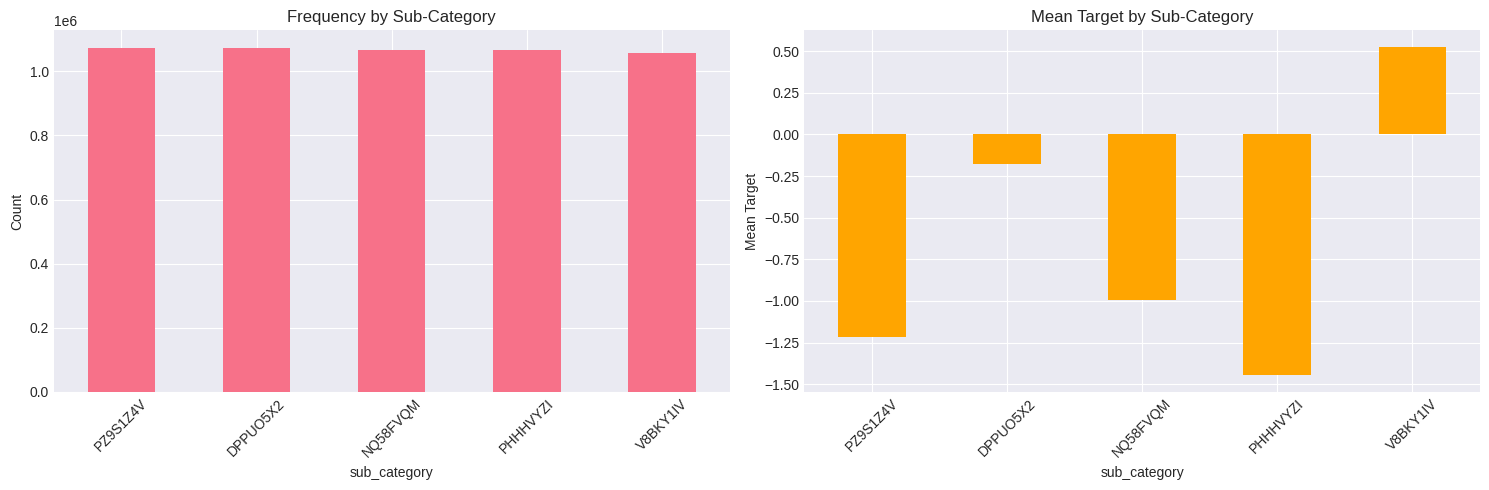

In [19]:
# Target by sub_category
subcat_stats = train.groupby('sub_category')['y_target'].agg(['count', 'mean', 'std'])
subcat_stats = subcat_stats.sort_values('count', ascending=False)

print('=== SUB_CATEGORY STATISTICS ===')
print(subcat_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

subcat_stats['count'].plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('Count')
axes[0].set_title('Frequency by Sub-Category')
axes[0].tick_params(axis='x', rotation=45)

subcat_stats['mean'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_ylabel('Mean Target')
axes[1].set_title('Mean Target by Sub-Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Key Insights Summary

In [20]:
print('=' * 80)
print('KEY INSIGHTS FOR MODELING')
print('=' * 80)

print('\n1. TEMPORAL STRUCTURE:')
print(f'   - Training period: ts_index {train["ts_index"].min()} to {train["ts_index"].max()}')
print(f'   - Test period: ts_index {test["ts_index"].min()} to {test["ts_index"].max()}')
print(f'   - Test is AFTER train: {test["ts_index"].min() > train["ts_index"].max()}')
print('   → Use time-based validation, no random CV')

print('\n2. TARGET CHARACTERISTICS:')
print(f'   - Mean: {train["y_target"].mean():.6f}')
print(f'   - Std: {train["y_target"].std():.6f}')
print(f'   - Coefficient of Variation: {train["y_target"].std() / abs(train["y_target"].mean()):.2f}')
print('   → High noise-to-signal ratio, use smoothing techniques')

print('\n3. HORIZONS:')
for h in sorted(train['horizon'].unique()):
    h_data = train[train['horizon'] == h]
    print(f'   - Horizon {h}: {len(h_data)} samples, mean target = {h_data["y_target"].mean():.6f}')
print('   → Different horizons may need different features/models')

print('\n4. MISSING VALUES:')
print(f'   - Features with missing values: {(train.isnull().sum() > 0).sum()}')
print(f'   - Max missing rate: {missing_train_pct.max():.2f}%')
print('   → Handle missing values carefully, median/mean imputation')

print('\n5. FEATURE IMPORTANCE:')
print(f'   - Top feature correlation: {correlations.abs().max():.3f}')
print(f'   - Features with |corr| > 0.01: {(correlations.abs() > 0.01).sum()}')
print('   → Weak individual correlations, focus on feature engineering')

print('\n6. CATEGORIES:')
print(f'   - {train["code"].nunique()} unique codes')
print(f'   - {train["sub_code"].nunique()} unique sub_codes')
print(f'   - {train["sub_category"].nunique()} unique sub_categories')
print('   → Use category aggregations and encoding')

print('\n' + '=' * 80)

KEY INSIGHTS FOR MODELING

1. TEMPORAL STRUCTURE:
   - Training period: ts_index 1 to 3601
   - Test period: ts_index 3602 to 4376
   - Test is AFTER train: True
   → Use time-based validation, no random CV

2. TARGET CHARACTERISTICS:
   - Mean: -0.665905
   - Std: 32.527642
   - Coefficient of Variation: 48.85
   → High noise-to-signal ratio, use smoothing techniques

3. HORIZONS:
   - Horizon 1: 1394653 samples, mean target = -0.082721
   - Horizon 3: 1385816 samples, mean target = -0.252409
   - Horizon 10: 1337236 samples, mean target = -0.775965
   - Horizon 25: 1219709 samples, mean target = -1.681878
   → Different horizons may need different features/models

4. MISSING VALUES:
   - Features with missing values: 48
   - Max missing rate: 12.47%
   → Handle missing values carefully, median/mean imputation

5. FEATURE IMPORTANCE:
   - Top feature correlation: 0.090
   - Features with |corr| > 0.01: 36
   → Weak individual correlations, focus on feature engineering

6. CATEGORIES:


## 8. Recommendations

Based on the analysis:

### Feature Engineering
1. **Lag features**: Critical for time series
2. **Rolling aggregations**: Reduce noise (windows: 3, 7, 14)
3. **Category aggregations**: Leverage similarities
4. **Horizon-specific features**: Different patterns per horizon

### Modeling
1. **Time-based CV**: Respect temporal ordering
2. **Gradient boosting**: LightGBM, XGBoost
3. **Ensemble**: Average multiple models
4. **Custom metric**: Use weighted RMSE

### Strategy
1. **Focus on recent data**: Weights or time-based sampling
2. **Handle noise**: Smoothing, regularization
3. **Category awareness**: Separate models or features
4. **Validate properly**: Use same metric as competition